# Video Game Sales Analysis with DuckDB

An additional exploratory analysis using DuckDB SQL and Python visualisation to compare genre, platform, publisher and regional sales patterns over time.

**Environment note:** This notebook was originally developed in Google Colab. Upload and download cells may require Colab, while the analysis logic is standard Python/SQL.


In [ ]:
import pandas as pd
import duckdb
from google.colab import files

# This will open a file upload dialog. Please upload 'vgsales.xlsx'.
print("Please upload the 'vgsales.xlsx' file:")
uploaded = files.upload()

# Get the name of the first uploaded file.
# Assuming 'vgsales.xlsx' is the file you are uploading.
filename = next(iter(uploaded))

df = pd.read_excel(filename)   # Use the uploaded file's name

con = duckdb.connect()
con.register("vgsales", df)

In [4]:
query = """
SELECT
    Genre,
    Platform,
    SUM(NA_Sales) AS NA_Sales,
    SUM(EU_Sales) AS EU_Sales,

    SUM(JP_Sales) AS JP_Sales,
    SUM(Other_Sales) AS Other_Sales,
    SUM(Global_Sales) AS Global_Sales
FROM vgsales
GROUP BY Genre, Platform
ORDER BY Global_Sales DESC;
"""

regional_sales = con.execute(query).df()
regional_sales.head()

,Genre,Platform,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Action,PS3,121.16,110.62,29.59,46.51,307.88
1,Sports,Wii,151.77,94.99,18.25,27.06,292.06
2,Shooter,X360,174.22,76.59,3.10,24.53,278.55
3,Sports,PS2,134.12,69.96,24.74,44.66,273.41
4,Action,PS2,127.82,71.44,25.81,47.64,272.76


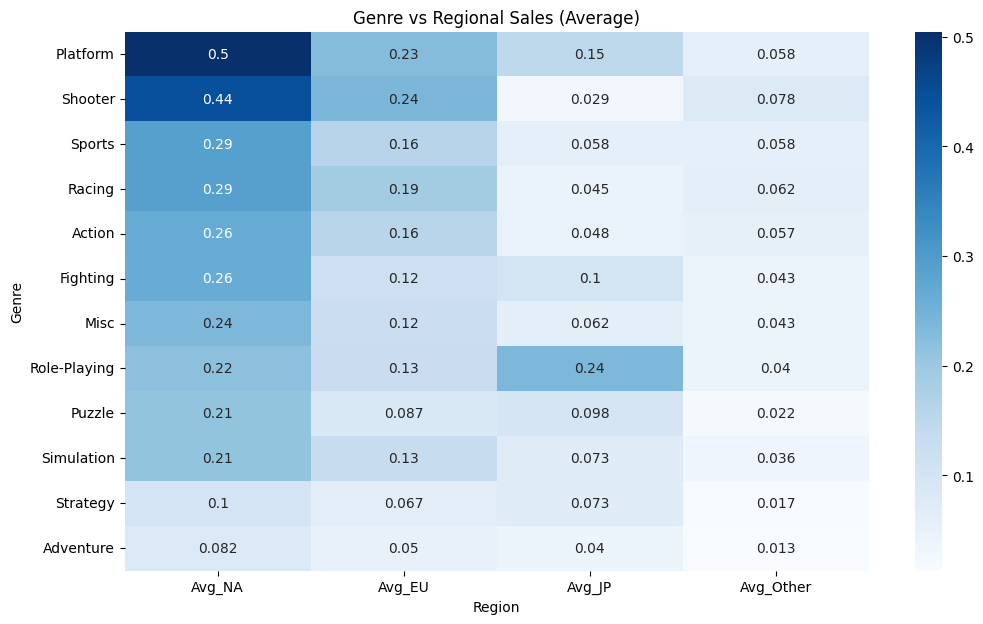

Saved: visuals/genre_region_heatmap.png


<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder for all visuals
os.makedirs("visuals", exist_ok=True)

def save_fig(name):
    """Save matplotlib figure to the visuals folder."""
    filepath = f"visuals/{name}.png"
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved: {filepath}")

query = """
SELECT
    Genre,
    AVG(NA_Sales) AS Avg_NA,
    AVG(EU_Sales) AS Avg_EU,
    AVG(JP_Sales) AS Avg_JP,
    AVG(Other_Sales) AS Avg_Other
FROM vgsales
GROUP BY Genre
ORDER BY Avg_NA DESC;
"""

genre_region_matrix = con.execute(query).df()
genre_region_matrix

genre_matrix = con.execute(query).df().set_index("Genre")

# Plot
plt.figure(figsize=(12,7))
sns.heatmap(genre_matrix, annot=True, cmap="Blues")
plt.title("Genre vs Regional Sales (Average)")
plt.ylabel("Genre")
plt.xlabel("Region")
plt.show()
save_fig("genre_region_heatmap") # Save the figure

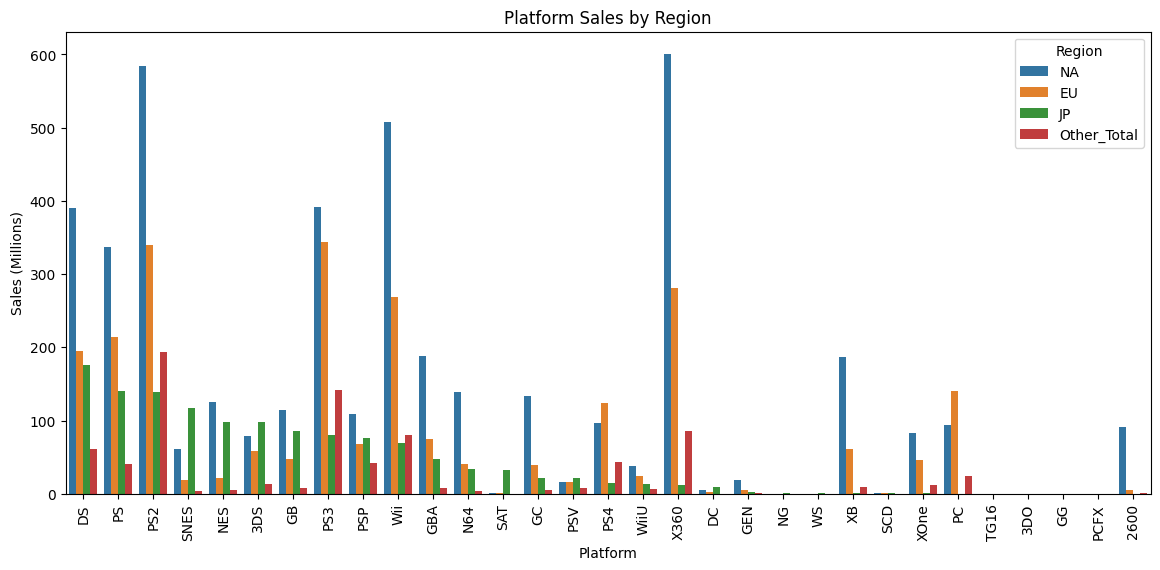

Saved: visuals/regional_sales_bar_chart.png


<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

query = """
SELECT
    Platform,
    SUM(NA_Sales) AS NA,
    SUM(EU_Sales) AS EU,
    SUM(JP_Sales) AS JP,
    SUM(Other_Sales) AS Other_Total
FROM vgsales
GROUP BY Platform
ORDER BY JP DESC;
"""

platform_bias = con.execute(query).df()
platform_bias


# Melt for seaborn
melted = platform_bias.melt(id_vars="Platform",
                              var_name="Region",
                              value_name="Sales")

# Plot
plt.figure(figsize=(14,6))
sns.barplot(data=melted, x="Platform", y="Sales", hue="Region")
plt.title("Platform Sales by Region")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=90)
plt.show()
save_fig("regional_sales_bar_chart") # Save the figure

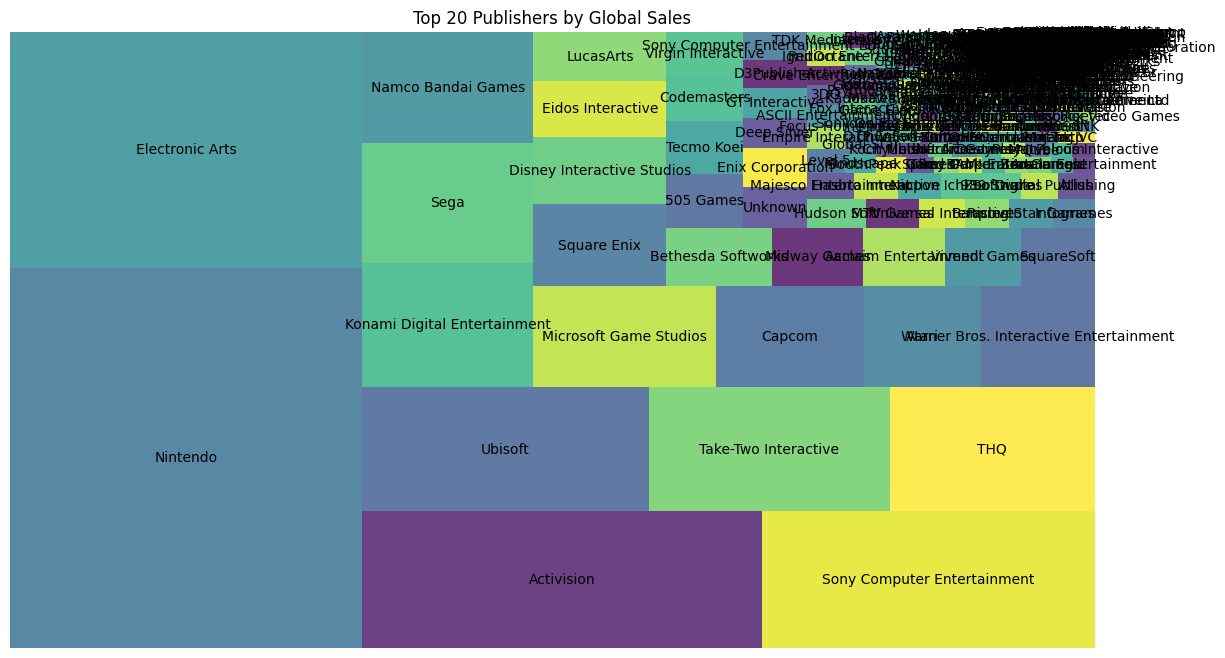

In [15]:
!pip install squarify
import squarify
import matplotlib.pyplot as plt

query = """
SELECT
    Publisher,
    SUM(Global_Sales) AS GlobalSales,
    SUM(NA_Sales) AS NA,
    SUM(EU_Sales) AS EU,
    SUM(JP_Sales) AS JP,
    SUM(Other_Sales) AS OtherSales
FROM vgsales
GROUP BY Publisher
ORDER BY GlobalSales DESC;
"""

publisher_geo = con.execute(query).df()
publisher_geo

# Plot
plt.figure(figsize=(14,8))
squarify.plot(sizes=publisher_geo["GlobalSales"],
              label=publisher_geo["Publisher"],
              alpha=0.8)
plt.title("Top 20 Publishers by Global Sales")
plt.axis("off")
plt.show()

In [16]:
regional_sales.to_excel("regional_sales.xlsx", index=False)
genre_region_matrix.to_excel("genre_region_matrix.xlsx", index=False)
platform_bias.to_excel("platform_bias.xlsx", index=False)
publisher_geo.to_excel("publisher_geo.xlsx", index=False)

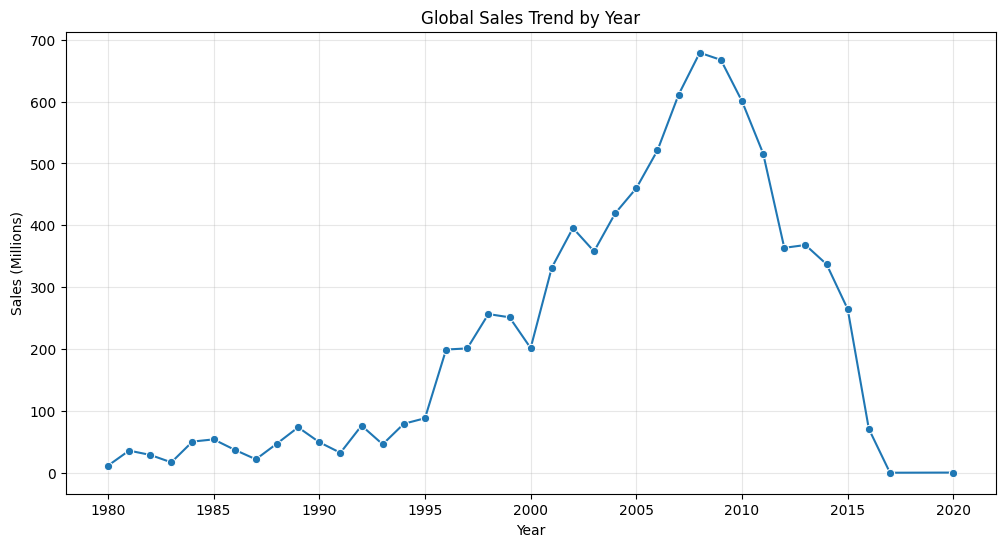

Saved: visuals/yearly_global_sales_trend.png


<Figure size 640x480 with 0 Axes>

In [14]:
# Query
query = """
SELECT
    Year,
    SUM(Global_Sales) AS GlobalSales
FROM vgsales
WHERE Year IS NOT NULL
GROUP BY Year
ORDER BY Year;
"""

trend = con.execute(query).df()
trend

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=trend, x="Year", y="GlobalSales", marker="o")
plt.title("Global Sales Trend by Year")
plt.ylabel("Sales (Millions)")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.show()
save_fig("yearly_global_sales_trend") # Save the figure

In [11]:
import matplotlib.pyplot as plt
import os

# Create folder for all visuals
os.makedirs("visuals", exist_ok=True)

def save_fig(name):
    """Save matplotlib figure to the visuals folder."""
    filepath = f"visuals/{name}.png"
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved: {filepath}")

In [17]:
from google.colab import files
files.download("visuals/regional_sales_bar_chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from google.colab import files
files.download("visuals/regional_sales_bar_chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>